# Task 1: Multi-feature Modelling for Triage Acuity Prediction

This notebook reproduces the previous group's modelling approach for Task 1 triage acuity prediction.

The main purpose is to test whether our current Task 1 dataset can reproduce a similar machine learning pipeline using chief complaint one-hot encoding, vital signs, and early patient information.

Following the previous group's approach, the modelling process uses:

- one-hot encoded chief complaint features,
- vital signs,
- selected early categorical features,
- acuity levels 1–4 as the target classes.

Acuity level 5 is excluded in this reproduction experiment because the previous group's final model was a four-class acuity prediction model.

## Step 1: Import required libraries

This step imports the libraries used for data processing, model training, evaluation, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## Step 2: Load the final Task 1 dataset

This step loads the final Task 1 dataset with cleaned chief complaint text and extracted vital sign features.

In [2]:
DATA_PATH = "task1_acuity_with_vitals.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (106284, 17)


,subject_id,hadm_id,stay_id,gender,arrival_transport,chiefcomplaint,chief_complaint,chief_text,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,raw_row_length
0,16070390,20482734,NaN,F,AMBULANCE,s/p Fall,"trauma, hypoxia","s/p fall [SEP] trauma, hypoxia",98.5,83.0,18.0,98.0,163.0,45.0,3.0,2,949
1,19249493,27215580,NaN,F,WALK IN,Abd pain,"abdominal pain radiating to back, nausea, vomi...",abd pain [SEP] abdominal pain radiating to bac...,98.8,112.0,20.0,99.0,120.0,74.0,8.0,3,949
2,17649604,26921204,38186397.0,F,AMBULANCE,"NSTEMI, Transfer","cool skin, nausea, malaise","nstemi, transfer [SEP] cool skin, nausea, malaise",98.7,90.0,16.0,98.0,116.0,58.0,0.0,2,947
3,17392822,28381240,NaN,M,WALK IN,"Dyspnea, Chest pain","dyspnea on exertion, pleuritic chest pain, pro...","dyspnea, chest pain [SEP] dyspnea on exertion,...",98.8,95.0,20.0,100.0,119.0,64.0,7.0,2,948
4,16237818,29461643,NaN,F,WALK IN,BRBPR,"loose, bloody stools","brbpr [SEP] loose, bloody stools",97.7,79.0,20.0,97.0,140.0,76.0,0.0,2,947


## Check dataset information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106284 entries, 0 to 106283
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   subject_id         106284 non-null  int64  
 1   hadm_id            106284 non-null  object 
 2   stay_id            19469 non-null   float64
 3   gender             106284 non-null  object 
 4   arrival_transport  106284 non-null  object 
 5   chiefcomplaint     106282 non-null  object 
 6   chief_complaint    106283 non-null  object 
 7   chief_text         106284 non-null  object 
 8   temperature        103666 non-null  float64
 9   heartrate          106284 non-null  float64
 10  resprate           104778 non-null  float64
 11  o2sat              104769 non-null  float64
 12  sbp                105704 non-null  float64
 13  dbp                105480 non-null  float64
 14  pain               100808 non-null  float64
 15  acuity             106284 non-null  int64  
 16  ra

## Display all column names

In [4]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'gender', 'arrival_transport',
       'chiefcomplaint', 'chief_complaint', 'chief_text', 'temperature',
       'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity',
       'raw_row_length'],
      dtype='object')

## Check missing values

In [5]:
missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2)
})

missing_summary

,column,missing_count,missing_percent
0,subject_id,0,0.00
1,hadm_id,0,0.00
2,stay_id,86815,81.68
3,gender,0,0.00
4,arrival_transport,0,0.00
5,chiefcomplaint,2,0.00
6,chief_complaint,1,0.00
7,chief_text,0,0.00
8,temperature,2618,2.46
9,heartrate,0,0.00


## Check original target label distribution

This step shows the original acuity distribution before previous-group-style filtering.

At this stage, acuity level 5 is still present in the raw dataset. It will be excluded later during the modelling dataset preparation to match the previous group's four-class classification setting.

In [6]:
# Check original target label distribution before filtering

acuity_counts_original = df["acuity"].value_counts().sort_index()

print(acuity_counts_original)

acuity
1     8998
2    53927
3    43020
4      332
5        7
Name: count, dtype: int64


## Visualise acuity distribution

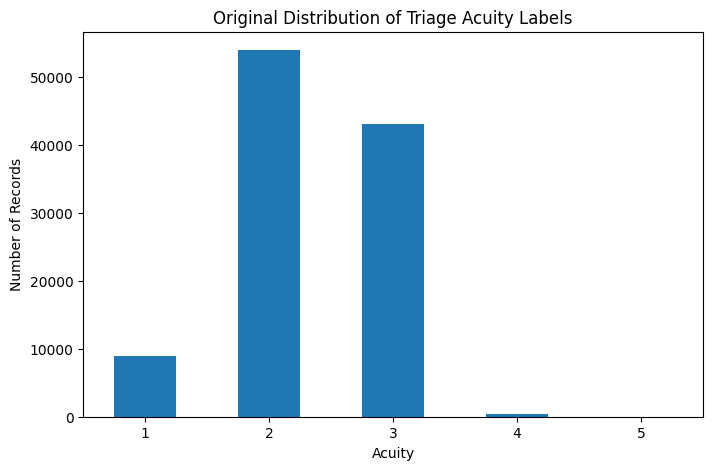

In [7]:
# Visualise original acuity distribution before filtering

plt.figure(figsize=(8, 5))
acuity_counts_original.plot(kind="bar")
plt.title("Original Distribution of Triage Acuity Labels")
plt.xlabel("Acuity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## Step 3: Prepare the modelling dataset

This step prepares the final modelling dataset using a similar data preparation strategy to the previous group.

Starting from the original Task 1 dataset, this step applies the following processing:

1. Converts `chiefcomplaint` to lowercase and prepares it for one-hot encoding.
2. Converts `acuity` and vital sign features into numeric values.
3. Removes records with missing acuity or missing vital signs.
4. Removes obvious vital sign outliers.
5. Excludes acuity level 5 to match the previous group's four-class classification setting.
6. Converts chief complaint into one-hot encoded features and keeps only frequent complaint features.
7. Adds selected early categorical features, including gender and arrival transport.

After this step, the final modelling task uses acuity levels 1 to 4.

These preprocessing steps make the dataset cleaner and closer to the previous group's modelling approach. Missing vital signs and obvious outliers are removed to improve data quality. Acuity level 5 is excluded so that the task becomes a four-class classification problem, matching the previous group's setting.

Chief complaint, gender, and arrival transport are converted into one-hot encoded features so that traditional machine learning models can use them. This allows the models to learn patterns between presenting complaints, early clinical information, and triage acuity.

However, these steps also reduce the number of records and may remove some rare complaint categories. Therefore, the final dataset is cleaner and more comparable with the previous group, but it may lose some information from rare or incomplete cases.

Final modelling dataset shape: (78252, 161)

Final acuity distribution after filtering:


,Count
acuity,
1,4520
2,40851
3,32680
4,201



Number of retained chief complaint features: 144
Number of categorical dummy features: 9
Number of numeric vital sign features: 7
Total number of multi-feature inputs: 160


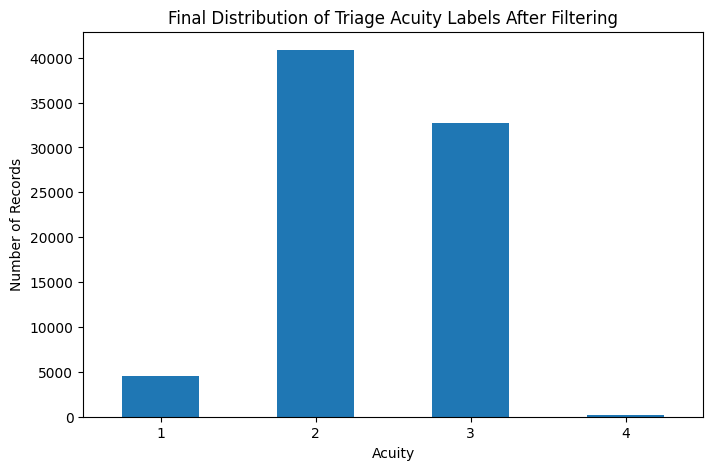

In [8]:
# Create a copy of the original dataset for modelling
df_model = df.copy()

# Store record counts at each processing stage for later reporting
record_log = []

def log_records(stage_name, data):
    record_log.append({
        "Stage": stage_name,
        "Records": len(data)
    })

log_records("Original dataset", df_model)


# -------------------------------
# 1. Clean chief complaint text
# -------------------------------

df_model["chiefcomplaint_clean"] = (
    df_model["chiefcomplaint"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

# Standardise comma spacing for one-hot encoding
df_model["chiefcomplaint_clean"] = (
    df_model["chiefcomplaint_clean"]
    .str.replace(r"\s*,\s*", ", ", regex=True)
)

# Remove empty or redacted chief complaints
df_model = df_model[df_model["chiefcomplaint_clean"] != ""]
df_model = df_model[~df_model["chiefcomplaint_clean"].str.contains("___", na=False)]

log_records("After removing empty or redacted chief complaints", df_model)


# -------------------------------
# 2. Convert target and vital signs to numeric values
# -------------------------------

numeric_features = [
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain"
]

df_model["acuity"] = pd.to_numeric(df_model["acuity"], errors="coerce")

for col in numeric_features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")


# -------------------------------
# 3. Remove missing acuity or missing vital signs
# -------------------------------

df_model = df_model.dropna(subset=["acuity"] + numeric_features)

# Convert acuity to integer labels
df_model["acuity"] = df_model["acuity"].astype(int)

log_records("After removing records with missing acuity or vital signs", df_model)


# -------------------------------
# 4. Remove obvious vital sign outliers
# -------------------------------

df_model = df_model[~((df_model["temperature"] < 40) | (df_model["temperature"] > 120))]
df_model = df_model[~((df_model["heartrate"] < 10) | (df_model["heartrate"] > 250))]
df_model = df_model[~((df_model["resprate"] < 5) | (df_model["resprate"] > 100))]
df_model = df_model[~((df_model["o2sat"] < 30) | (df_model["o2sat"] > 100))]
df_model = df_model[~((df_model["sbp"] < 20) | (df_model["sbp"] > 300))]
df_model = df_model[~(df_model["dbp"] > 200)]
df_model = df_model[~(df_model["pain"] > 10)]

log_records("After removing obvious vital sign outliers", df_model)


# -------------------------------
# 5. Exclude acuity level 5
# -------------------------------

df_model = df_model[df_model["acuity"].between(1, 4)]

log_records("After excluding acuity level 5", df_model)


# -------------------------------
# 6. One-hot encode chief complaint
# -------------------------------

complaint_dummies = df_model["chiefcomplaint_clean"].str.get_dummies(sep=", ")
complaint_dummies = complaint_dummies.add_prefix("cc_")


# Merge common abbreviations into standard complaint columns
def merge_complaint_abbreviation(source_col, target_col):
    if source_col in complaint_dummies.columns:
        if target_col not in complaint_dummies.columns:
            complaint_dummies[target_col] = 0

        complaint_dummies[target_col] = (
            complaint_dummies[target_col] + complaint_dummies[source_col]
        )

        complaint_dummies.drop(columns=[source_col], inplace=True)


merge_complaint_abbreviation("cc_cp", "cc_chest pain")
merge_complaint_abbreviation("cc_abd pain", "cc_abdominal pain")
merge_complaint_abbreviation("cc_abdo pain", "cc_abdominal pain")


# Keep only frequent chief complaint features
complaint_threshold = 100
complaint_counts = complaint_dummies.sum()

complaint_dummies = complaint_dummies.loc[
    :,
    complaint_counts[complaint_counts >= complaint_threshold].index
]


# Remove records that do not contain any retained complaint feature
complaint_row_sum = complaint_dummies.sum(axis=1)

df_model = df_model.loc[complaint_row_sum > 0].copy()
complaint_dummies = complaint_dummies.loc[complaint_row_sum > 0].copy()

log_records("After retaining frequent chief complaint features", df_model)


# -------------------------------
# 7. One-hot encode early categorical features
# -------------------------------

df_model["gender_clean"] = (
    df_model["gender"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

df_model["arrival_transport_clean"] = (
    df_model["arrival_transport"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

categorical_dummies = pd.get_dummies(
    df_model[["gender_clean", "arrival_transport_clean"]],
    columns=["gender_clean", "arrival_transport_clean"],
    prefix=["gender", "transport"],
    dtype=int
)


# -------------------------------
# 8. Create the final modelling dataset
# -------------------------------

complaint_feature_columns = complaint_dummies.columns.tolist()
categorical_feature_columns = categorical_dummies.columns.tolist()

baseline_feature_columns = complaint_feature_columns
multi_feature_columns = numeric_features + categorical_feature_columns + complaint_feature_columns

df_model = pd.concat(
    [
        df_model[["acuity"] + numeric_features].reset_index(drop=True),
        categorical_dummies.reset_index(drop=True),
        complaint_dummies.reset_index(drop=True)
    ],
    axis=1
)


# -------------------------------
# 9. Display final dataset summary
# -------------------------------

print("Final modelling dataset shape:", df_model.shape)

print("\nFinal acuity distribution after filtering:")
acuity_counts_final = df_model["acuity"].value_counts().sort_index()
display(acuity_counts_final.to_frame("Count"))

print("\nNumber of retained chief complaint features:", len(complaint_feature_columns))
print("Number of categorical dummy features:", len(categorical_feature_columns))
print("Number of numeric vital sign features:", len(numeric_features))
print("Total number of multi-feature inputs:", len(multi_feature_columns))


# Visualise final acuity distribution
plt.figure(figsize=(8, 5))
acuity_counts_final.plot(kind="bar")
plt.title("Final Distribution of Triage Acuity Labels After Filtering")
plt.xlabel("Acuity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## Step 4: Check the filtering result

This step summarises how many records remain after each filtering stage.

The filtering process follows the previous group's approach more closely by removing records with missing vital signs, removing obvious outliers, excluding acuity level 5, and retaining only frequent chief complaint features.

This step also visualises the final acuity distribution after filtering.

,Stage,Records
0,Original dataset,106284
1,After removing empty or redacted chief complaints,106127
2,After removing records with missing acuity or ...,96490
3,After removing obvious vital sign outliers,92707
4,After excluding acuity level 5,92700
5,After retaining frequent chief complaint features,78252


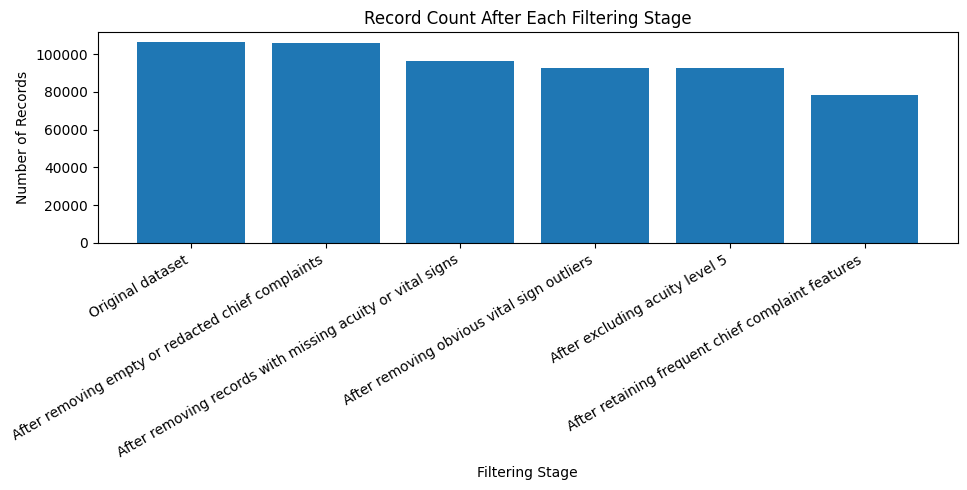

,Count,Percentage
acuity,,
1,4520,5.78
2,40851,52.20
3,32680,41.76
4,201,0.26


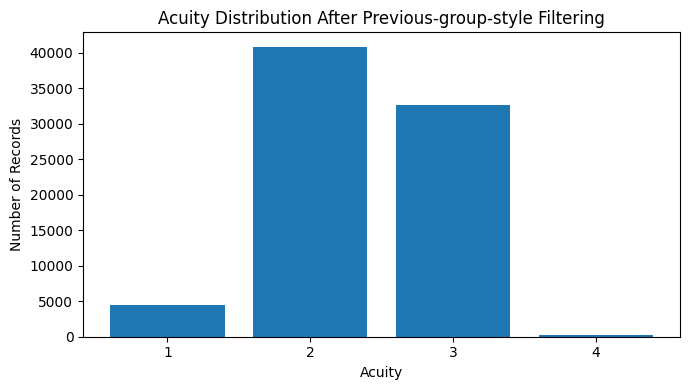

,count,mean,std,min,25%,50%,75%,max
temperature,78252.0,98.227000,1.196247,46.9,97.6,98.1,98.7,111.4
heartrate,78252.0,87.135905,19.144004,13.0,73.0,86.0,100.0,227.0
resprate,78252.0,18.030657,2.737014,8.0,16.0,18.0,18.0,80.0
o2sat,78252.0,97.774210,2.405038,57.0,97.0,98.0,100.0,100.0
sbp,78252.0,134.354841,24.576119,50.0,117.0,132.0,149.0,274.0
dbp,78252.0,74.962225,15.958757,0.0,64.0,74.0,85.0,198.0
pain,78252.0,3.626312,3.756932,0.0,0.0,3.0,7.0,10.0


In [9]:
# Display record counts after each data preparation stage
record_summary = pd.DataFrame(record_log)
display(record_summary)

# Visualise record count changes
plt.figure(figsize=(10, 5))
plt.bar(record_summary["Stage"], record_summary["Records"])
plt.title("Record Count After Each Filtering Stage")
plt.xlabel("Filtering Stage")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Display acuity distribution after filtering
acuity_summary = df_model["acuity"].value_counts().sort_index().to_frame("Count")
acuity_summary["Percentage"] = (acuity_summary["Count"] / acuity_summary["Count"].sum() * 100).round(2)

display(acuity_summary)

# Visualise final acuity distribution
plt.figure(figsize=(7, 4))
plt.bar(acuity_summary.index.astype(str), acuity_summary["Count"])
plt.title("Acuity Distribution After Previous-group-style Filtering")
plt.xlabel("Acuity")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

# Check descriptive statistics for vital signs
display(df_model[numeric_features].describe().T)

## Step 5: Split the dataset into training and testing sets

This step creates one consistent 80/20 train-test split.

The complaint-only baseline uses only one-hot encoded chief complaint features. The multi-feature models use chief complaint features, vital signs, and early categorical features.

The same train-test split is used for all models so that the comparison is fair.

In [10]:
# Define target
y = df_model["acuity"]

# Complaint-only baseline input
X_baseline = df_model[baseline_feature_columns]

# Multi-feature model input
X_multi = df_model[multi_feature_columns]

# Create one shared stratified train-test split
train_index, test_index = train_test_split(
    df_model.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_baseline = X_baseline.loc[train_index]
X_test_baseline = X_baseline.loc[test_index]

X_train_multi = X_multi.loc[train_index]
X_test_multi = X_multi.loc[test_index]

y_train = y.loc[train_index]
y_test = y.loc[test_index]

class_labels = sorted(y.unique())

print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

print("\nTraining acuity distribution:")
display(y_train.value_counts().sort_index().to_frame("Train Count"))

print("\nTesting acuity distribution:")
display(y_test.value_counts().sort_index().to_frame("Test Count"))

Training samples: 62601
Testing samples: 15651

Training acuity distribution:


,Train Count
acuity,
1,3616
2,32680
3,26144
4,161



Testing acuity distribution:


,Test Count
acuity,
1,904
2,8171
3,6536
4,40


## Step 6: Define evaluation functions

This step defines reusable functions for evaluating each model.

Since the previous-group-style dataset has already been converted into numeric features, no TF-IDF pipeline or median imputation pipeline is used in this step.

The evaluation includes accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, classification report, confusion matrix, and training-testing accuracy comparison.

In [11]:
# Store model results for later comparison
model_results = []

BASELINE_MODEL_NAME = "Complaint-only Logistic Regression Baseline"

def add_result(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Calculate and store the main evaluation metrics for one model."""
    result = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train_true, y_train_pred),
        "Test Accuracy": accuracy_score(y_test_true, y_test_pred),
        "Macro Precision": precision_score(y_test_true, y_test_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test_true, y_test_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test_true, y_test_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test_true, y_test_pred, average="weighted", zero_division=0)
    }
    model_results.append(result)
    return result


def evaluate_predictions(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Display numeric metrics and visualisations for one model."""
    result = add_result(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred)

    print(model_name)
    print("=" * len(model_name))

    print("\nMain metrics:")
    display(pd.DataFrame([result]))

    print("\nClassification report:")
    print(classification_report(y_test_true, y_test_pred, labels=class_labels, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test_true, y_test_pred, labels=class_labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    # Training vs testing accuracy
    accuracy_df = pd.DataFrame({
        "Dataset": ["Training", "Testing"],
        "Accuracy": [result["Train Accuracy"], result["Test Accuracy"]]
    })

    plt.figure(figsize=(6, 4))
    plt.bar(accuracy_df["Dataset"], accuracy_df["Accuracy"])
    plt.ylim(0, 1)
    plt.title(f"Training vs Testing Accuracy - {model_name}")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

    return result


def compare_with_baseline(model_name):
    """Compare one model's test accuracy with the complaint-only baseline."""
    results_df = pd.DataFrame(model_results)
    baseline_row = results_df[results_df["Model"] == BASELINE_MODEL_NAME].iloc[0]
    model_row = results_df[results_df["Model"] == model_name].iloc[0]

    comparison_df = pd.DataFrame({
        "Model": [baseline_row["Model"], model_row["Model"]],
        "Test Accuracy": [baseline_row["Test Accuracy"], model_row["Test Accuracy"]],
        "Macro F1": [baseline_row["Macro F1"], model_row["Macro F1"]],
        "Weighted F1": [baseline_row["Weighted F1"], model_row["Weighted F1"]]
    })

    comparison_df["Test Accuracy Difference from Baseline"] = (
        comparison_df["Test Accuracy"] - baseline_row["Test Accuracy"]
    )

    display(comparison_df.round(4))

    plt.figure(figsize=(8, 4))
    plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
    plt.ylim(0, 1)
    plt.title(f"Test Accuracy Comparison: Baseline vs {model_name}")
    plt.ylabel("Test Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    print("Test accuracy difference from baseline:")
    print(round(model_row["Test Accuracy"] - baseline_row["Test Accuracy"], 4))

## Step 7: Train the complaint-only Logistic Regression baseline

This step trains the baseline model using only the one-hot encoded chief complaint features.

This baseline is used to test how much predictive information can be obtained from chief complaint categories alone. Later multi-feature models are compared against this baseline to assess whether adding vital signs and early categorical features improves performance.

In [12]:
baseline_model = LogisticRegression(
    max_iter=1000,
    solver="newton-cholesky",
    random_state=42
)

baseline_model.fit(X_train_baseline, y_train)

print("Complaint-only Logistic Regression baseline has been trained.")

Complaint-only Logistic Regression baseline has been trained.


## Step 8: Evaluate the complaint-only Logistic Regression baseline

This step evaluates the complaint-only baseline model using accuracy, precision, recall, F1-score, and a confusion matrix.

This result provides the reference point for all later multi-feature models.

Complaint-only Logistic Regression Baseline

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Complaint-only Logistic Regression Baseline,0.677944,0.685388,0.474954,0.37351,0.375442,0.667798



Classification report:
              precision    recall  f1-score   support

           1       0.53      0.05      0.10       904
           2       0.69      0.78      0.73      8171
           3       0.69      0.66      0.68      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.69     15651
   macro avg       0.47      0.37      0.38     15651
weighted avg       0.68      0.69      0.67     15651



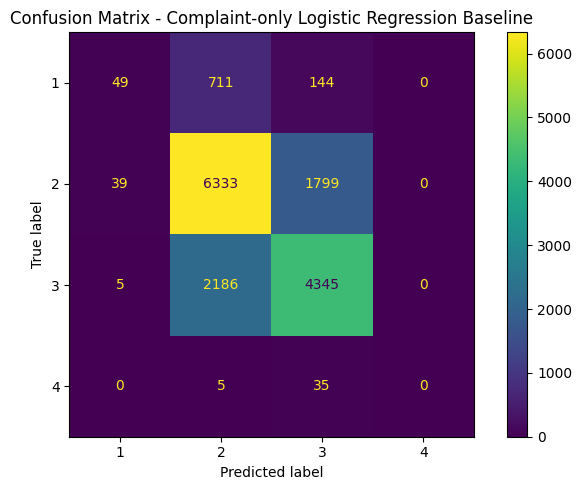

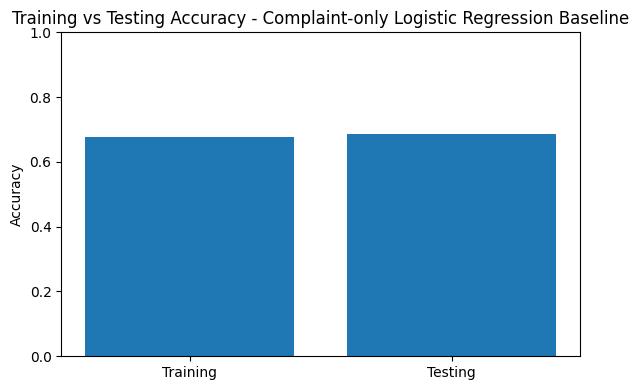

In [13]:
y_train_pred_baseline = baseline_model.predict(X_train_baseline)
y_test_pred_baseline = baseline_model.predict(X_test_baseline)

baseline_result = evaluate_predictions(
    BASELINE_MODEL_NAME,
    y_train,
    y_train_pred_baseline,
    y_test,
    y_test_pred_baseline
)

## Step 9: Train the multi-feature Logistic Regression model

This step trains Logistic Regression using chief complaint one-hot features, vital signs, and early categorical features.

This model is the direct multi-feature extension of the complaint-only baseline.

In [14]:
logistic_model = LogisticRegression(
    max_iter=1000,
    solver="newton-cholesky",
    random_state=42
)

logistic_model.fit(X_train_multi, y_train)

print("Multi-feature Logistic Regression model has been trained.")

Multi-feature Logistic Regression model has been trained.


## Step 10: Evaluate the multi-feature Logistic Regression model

This step evaluates the multi-feature Logistic Regression model and compares it with the text-only baseline.

Multi-feature Logistic Regression

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-feature Logistic Regression,0.68828,0.692288,0.493359,0.404186,0.419825,0.68203



Classification report:
              precision    recall  f1-score   support

           1       0.59      0.17      0.26       904
           2       0.70      0.75      0.73      8171
           3       0.68      0.70      0.69      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.69     15651
   macro avg       0.49      0.40      0.42     15651
weighted avg       0.69      0.69      0.68     15651



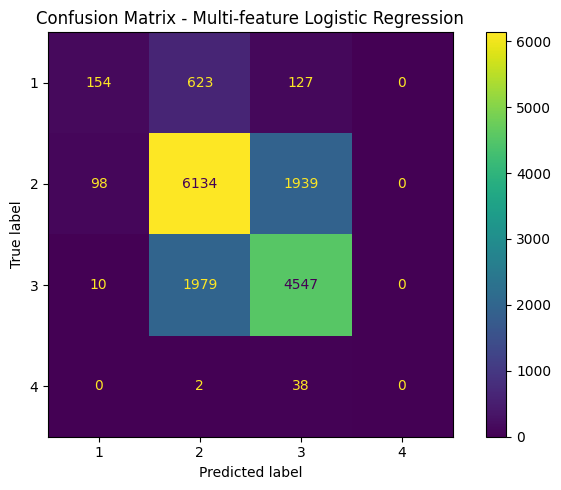

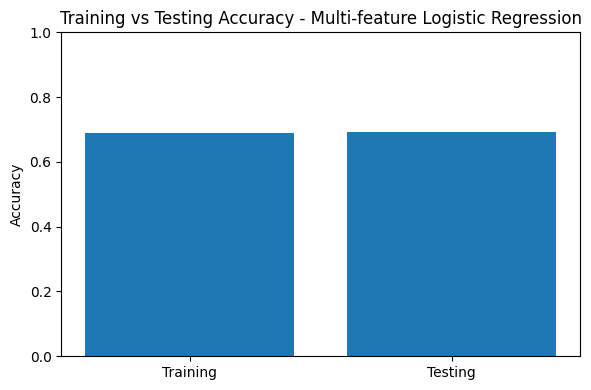


Comparison with text-only baseline:


,Model,Test Accuracy,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Complaint-only Logistic Regression Baseline,0.6854,0.3754,0.6678,0.0000
1,Multi-feature Logistic Regression,0.6923,0.4198,0.6820,0.0069


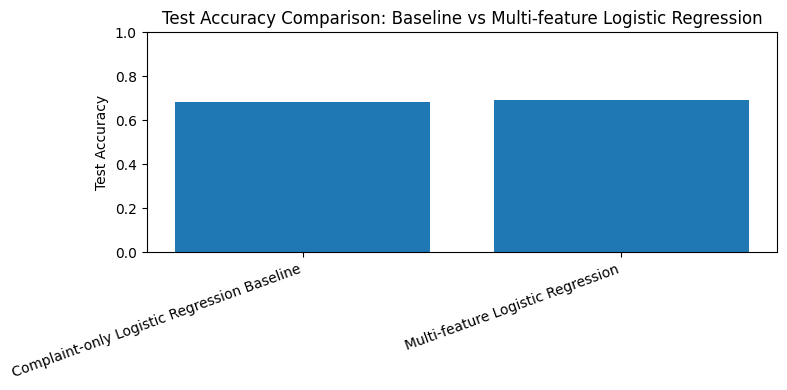

Test accuracy difference from baseline:
0.0069


In [15]:
y_train_pred_logistic = logistic_model.predict(X_train_multi)
y_test_pred_logistic = logistic_model.predict(X_test_multi)

logistic_result = evaluate_predictions(
    "Multi-feature Logistic Regression",
    y_train,
    y_train_pred_logistic,
    y_test,
    y_test_pred_logistic
)

print("\nComparison with text-only baseline:")
compare_with_baseline("Multi-feature Logistic Regression")

## Step 11: Train the multi-feature Decision Tree model

This step trains a Decision Tree model using the previous-group-style multi-feature dataset.

The model uses cost-complexity pruning through `ccp_alpha` to reduce overfitting.

In [16]:
decision_tree_model = DecisionTreeClassifier(
    ccp_alpha=0.0001,
    random_state=42
)

decision_tree_model.fit(X_train_multi, y_train)

print("Multi-feature Decision Tree model has been trained.")

Multi-feature Decision Tree model has been trained.


## Step 12: Evaluate the multi-feature Decision Tree model

This step evaluates the Decision Tree model and compares it with the text-only baseline.

Multi-feature Decision Tree

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-feature Decision Tree,0.690804,0.68756,0.526871,0.495222,0.509046,0.686388



Classification report:
              precision    recall  f1-score   support

           1       0.74      0.60      0.66       904
           2       0.70      0.72      0.71      8171
           3       0.66      0.66      0.66      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.69     15651
   macro avg       0.53      0.50      0.51     15651
weighted avg       0.69      0.69      0.69     15651



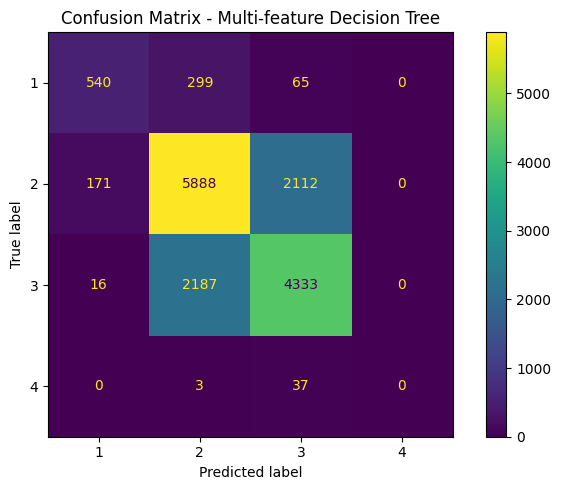

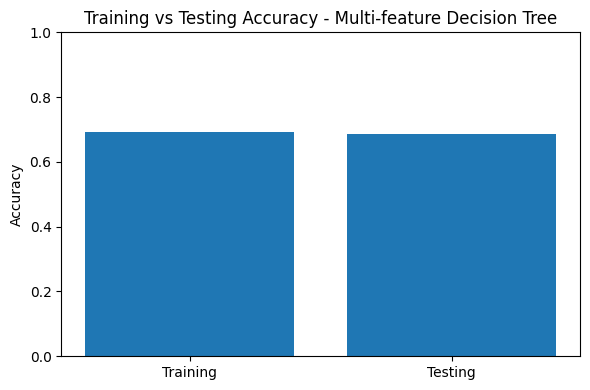


Comparison with text-only baseline:


,Model,Test Accuracy,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Complaint-only Logistic Regression Baseline,0.6854,0.3754,0.6678,0.0000
1,Multi-feature Decision Tree,0.6876,0.5090,0.6864,0.0022


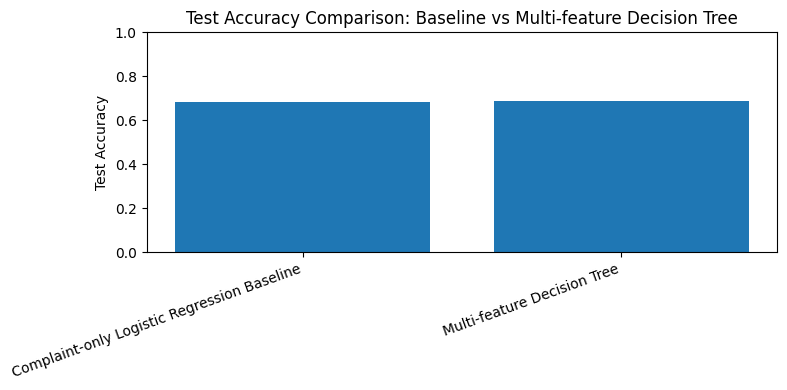

Test accuracy difference from baseline:
0.0022


In [17]:
y_train_pred_dt = decision_tree_model.predict(X_train_multi)
y_test_pred_dt = decision_tree_model.predict(X_test_multi)

decision_tree_result = evaluate_predictions(
    "Multi-feature Decision Tree",
    y_train,
    y_train_pred_dt,
    y_test,
    y_test_pred_dt
)

print("\nComparison with text-only baseline:")
compare_with_baseline("Multi-feature Decision Tree")

## Step 13: Train the multi-feature Random Forest model

This step trains a Random Forest model using the previous-group-style multi-feature dataset.

The parameter settings are selected to be close to the previous group's model configuration.

In [18]:
random_forest_model = RandomForestClassifier(
    bootstrap=False,
    max_depth=100,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=1000,
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(X_train_multi, y_train)

print("Multi-feature Random Forest model has been trained.")

Multi-feature Random Forest model has been trained.


## Step 14: Evaluate the multi-feature Random Forest model

This step evaluates the Random Forest model and compares it with the text-only baseline.

Multi-feature Random Forest

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-feature Random Forest,0.836999,0.713437,0.541573,0.503312,0.519506,0.711693



Classification report:
              precision    recall  f1-score   support

           1       0.75      0.57      0.65       904
           2       0.72      0.76      0.74      8171
           3       0.70      0.69      0.69      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.71     15651
   macro avg       0.54      0.50      0.52     15651
weighted avg       0.71      0.71      0.71     15651



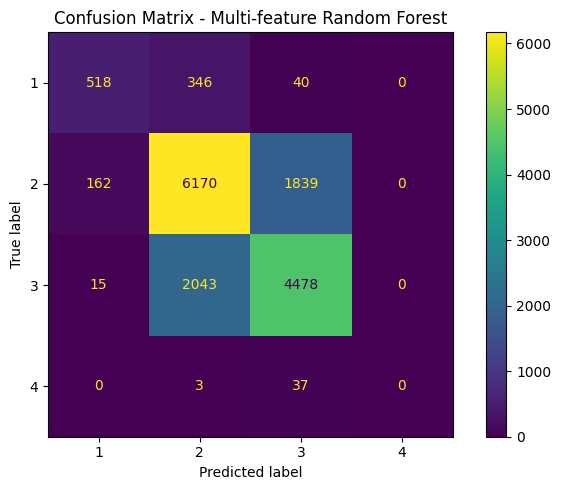

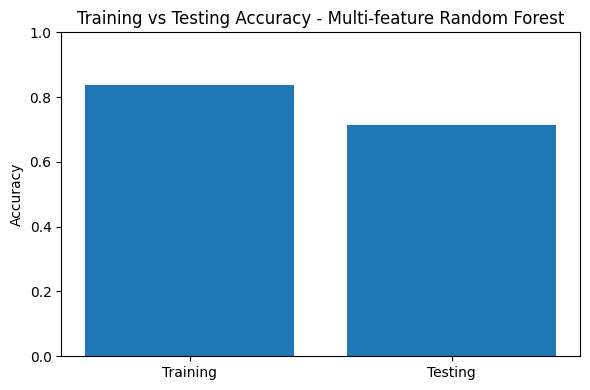


Comparison with text-only baseline:


,Model,Test Accuracy,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Complaint-only Logistic Regression Baseline,0.6854,0.3754,0.6678,0.000
1,Multi-feature Random Forest,0.7134,0.5195,0.7117,0.028


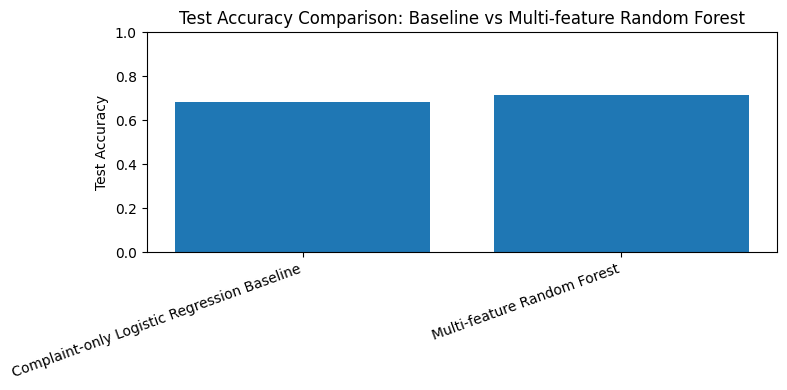

Test accuracy difference from baseline:
0.028


In [19]:
y_train_pred_rf = random_forest_model.predict(X_train_multi)
y_test_pred_rf = random_forest_model.predict(X_test_multi)

random_forest_result = evaluate_predictions(
    "Multi-feature Random Forest",
    y_train,
    y_train_pred_rf,
    y_test,
    y_test_pred_rf
)

print("\nComparison with text-only baseline:")
compare_with_baseline("Multi-feature Random Forest")

## Step 15: Train the multi-feature XGBoost model

This step trains an XGBoost model using the previous-group-style multi-feature dataset.

Because XGBoost requires class labels to start from 0, the acuity labels are encoded before training. The predictions are converted back to the original acuity labels during evaluation.

In [20]:
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

xgboost_model = XGBClassifier(
    n_estimators=800,
    eta=0.1,
    max_depth=6,
    subsample=0.5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgboost_model.fit(X_train_multi, y_train_xgb)

print("Multi-feature XGBoost model has been trained.")

Multi-feature XGBoost model has been trained.


## Step 16: Evaluate the multi-feature XGBoost model

This step evaluates the XGBoost model and compares it with the text-only baseline.

Multi-feature XGBoost

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-feature XGBoost,0.804604,0.715034,0.539595,0.503613,0.518946,0.713434



Classification report:
              precision    recall  f1-score   support

           1       0.73      0.57      0.64       904
           2       0.73      0.75      0.74      8171
           3       0.70      0.70      0.70      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.72     15651
   macro avg       0.54      0.50      0.52     15651
weighted avg       0.71      0.72      0.71     15651



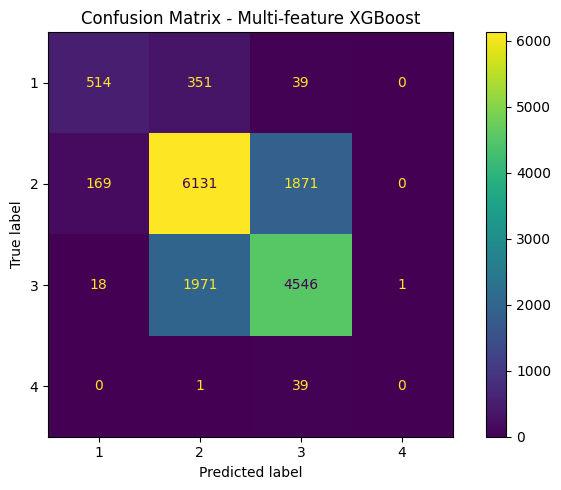

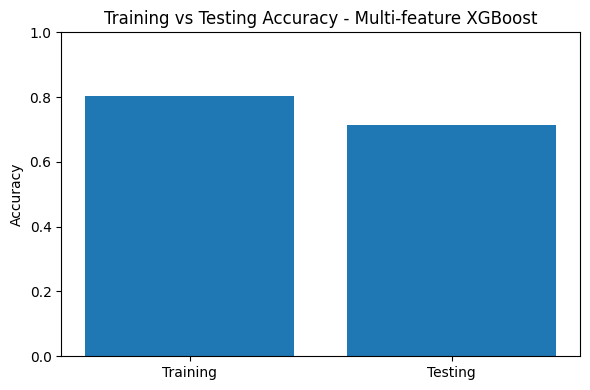


Comparison with complaint-only baseline:


,Model,Test Accuracy,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Complaint-only Logistic Regression Baseline,0.6854,0.3754,0.6678,0.0000
1,Multi-feature XGBoost,0.7150,0.5189,0.7134,0.0296


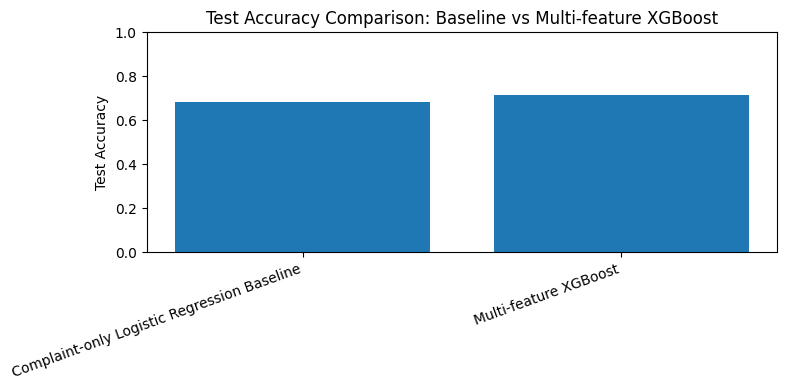

Test accuracy difference from baseline:
0.0296


In [21]:
# Predict encoded labels
y_train_pred_xgb_encoded = xgboost_model.predict(X_train_multi)
y_test_pred_xgb_encoded = xgboost_model.predict(X_test_multi)

# Convert encoded predictions back to original acuity labels
y_train_pred_xgb = label_encoder.inverse_transform(y_train_pred_xgb_encoded.astype(int))
y_test_pred_xgb = label_encoder.inverse_transform(y_test_pred_xgb_encoded.astype(int))

xgboost_result = evaluate_predictions(
    "Multi-feature XGBoost",
    y_train,
    y_train_pred_xgb,
    y_test,
    y_test_pred_xgb
)

print("\nComparison with complaint-only baseline:")
compare_with_baseline("Multi-feature XGBoost")

## Step 17: Hyperparameter tuning for XGBoost

This step performs hyperparameter tuning for the multi-feature XGBoost model.

The tuning is performed on the already-prepared previous-group-style numeric feature matrix. No additional TF-IDF or imputation pipeline is used.

`RandomizedSearchCV` is applied to the training set only. The test set remains unseen until the final tuned model evaluation.

In [22]:
xgb_tuning_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(class_labels),
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_param_grid = {
    "n_estimators": [400, 600, 800],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.5, 0.7, 0.9],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

xgb_search.fit(X_train_multi, y_train_xgb)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation accuracy:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'subsample': 0.5, 'reg_lambda': 5, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best cross-validation accuracy:
0.71022827111388


## Step 18: Evaluate the tuned XGBoost model

This step evaluates the tuned XGBoost model on the held-out test set.

Because XGBoost requires class labels to start from 0, the acuity labels were converted from `1–5` to `0–4` during training. After prediction, the predicted labels are converted back to the original acuity scale of `1–5` before evaluation.

The tuned model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Its performance is then compared with the original XGBoost model and the text-only Logistic Regression baseline.

Tuned Multi-feature XGBoost

Main metrics:


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Tuned Multi-feature XGBoost,0.748486,0.721168,0.545184,0.513167,0.527121,0.719688



Classification report:
              precision    recall  f1-score   support

           1       0.74      0.60      0.66       904
           2       0.73      0.76      0.74      8171
           3       0.71      0.70      0.70      6536
           4       0.00      0.00      0.00        40

    accuracy                           0.72     15651
   macro avg       0.55      0.51      0.53     15651
weighted avg       0.72      0.72      0.72     15651



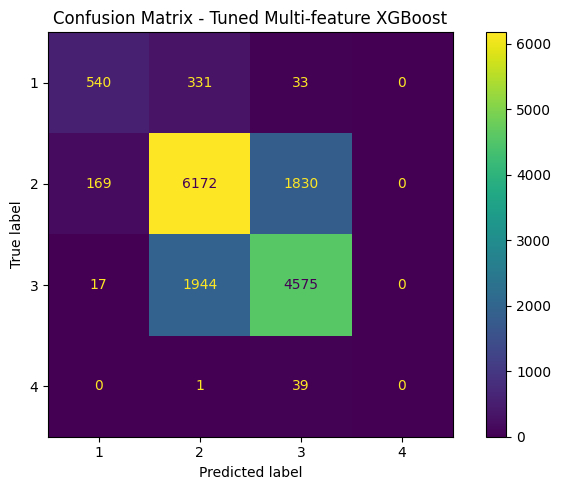

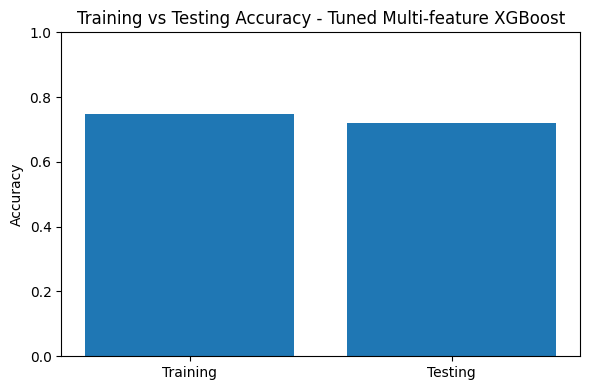


Comparison with complaint-only baseline:


,Model,Test Accuracy,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Complaint-only Logistic Regression Baseline,0.6854,0.3754,0.6678,0.0000
1,Tuned Multi-feature XGBoost,0.7212,0.5271,0.7197,0.0358


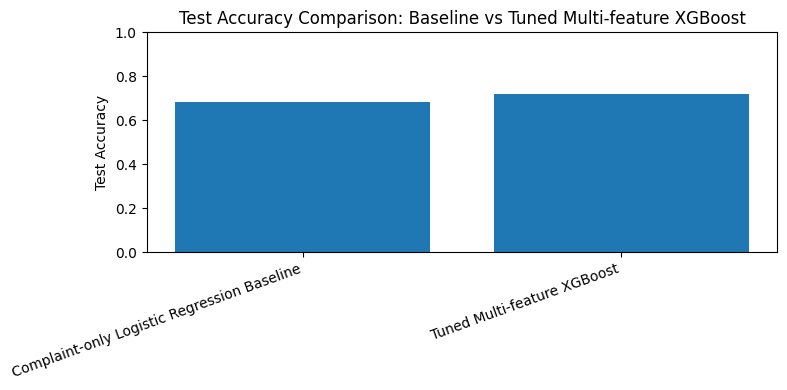

Test accuracy difference from baseline:
0.0358


In [23]:
best_xgb_model = xgb_search.best_estimator_

# Predict encoded labels
y_train_pred_xgb_tuned_encoded = best_xgb_model.predict(X_train_multi)
y_test_pred_xgb_tuned_encoded = best_xgb_model.predict(X_test_multi)

# Convert encoded predictions back to original acuity labels
y_train_pred_xgb_tuned = label_encoder.inverse_transform(y_train_pred_xgb_tuned_encoded.astype(int))
y_test_pred_xgb_tuned = label_encoder.inverse_transform(y_test_pred_xgb_tuned_encoded.astype(int))

tuned_xgb_result = evaluate_predictions(
    "Tuned Multi-feature XGBoost",
    y_train,
    y_train_pred_xgb_tuned,
    y_test,
    y_test_pred_xgb_tuned
)

print("\nComparison with complaint-only baseline:")
compare_with_baseline("Tuned Multi-feature XGBoost")

## Step 19: Compare all models

This step summarises the performance of the text-only baseline model and all multi-feature models.

The comparison includes training accuracy, testing accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, and the difference in testing accuracy compared with the text-only Logistic Regression baseline.

The purpose of this comparison is to determine whether adding vital signs and early categorical features improves triage acuity prediction compared with the baseline.

In [24]:
# Create a results DataFrame from all stored model results
results_df = pd.DataFrame(model_results)

# Remove duplicated model results if any model cell was run more than once
results_df = results_df.drop_duplicates(subset=["Model"], keep="last").reset_index(drop=True)

# Get the text-only Logistic Regression baseline accuracy
baseline_test_accuracy = results_df.loc[
    results_df["Model"] == BASELINE_MODEL_NAME,
    "Test Accuracy"
].iloc[0]

# Calculate the test accuracy difference from the baseline
results_df["Test Accuracy Difference from Baseline"] = (
    results_df["Test Accuracy"] - baseline_test_accuracy
)

# Sort models by test accuracy
results_df_sorted = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

# Display rounded results for readability
display(
    results_df_sorted.round({
        "Train Accuracy": 4,
        "Test Accuracy": 4,
        "Macro Precision": 4,
        "Macro Recall": 4,
        "Macro F1": 4,
        "Weighted F1": 4,
        "Test Accuracy Difference from Baseline": 4
    })
)

,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Test Accuracy Difference from Baseline
0,Tuned Multi-feature XGBoost,0.7485,0.7212,0.5452,0.5132,0.5271,0.7197,0.0358
1,Multi-feature XGBoost,0.8046,0.7150,0.5396,0.5036,0.5189,0.7134,0.0296
2,Multi-feature Random Forest,0.8370,0.7134,0.5416,0.5033,0.5195,0.7117,0.0280
3,Multi-feature Logistic Regression,0.6883,0.6923,0.4934,0.4042,0.4198,0.6820,0.0069
4,Multi-feature Decision Tree,0.6908,0.6876,0.5269,0.4952,0.5090,0.6864,0.0022
5,Complaint-only Logistic Regression Baseline,0.6779,0.6854,0.4750,0.3735,0.3754,0.6678,0.0000


## Step 20: Visualise the final model comparison

This step visualises the final comparison between the baseline model and the multi-feature models.

Three charts are generated:

1. Testing accuracy comparison across all models,
2. Macro F1-score comparison across all models,
3. Testing accuracy improvement or decrease compared with the text-only Logistic Regression baseline.

The testing accuracy chart shows the overall predictive performance. The macro F1-score chart is included because the acuity classes are highly imbalanced. The improvement chart shows whether each multi-feature model performs better or worse than the baseline.

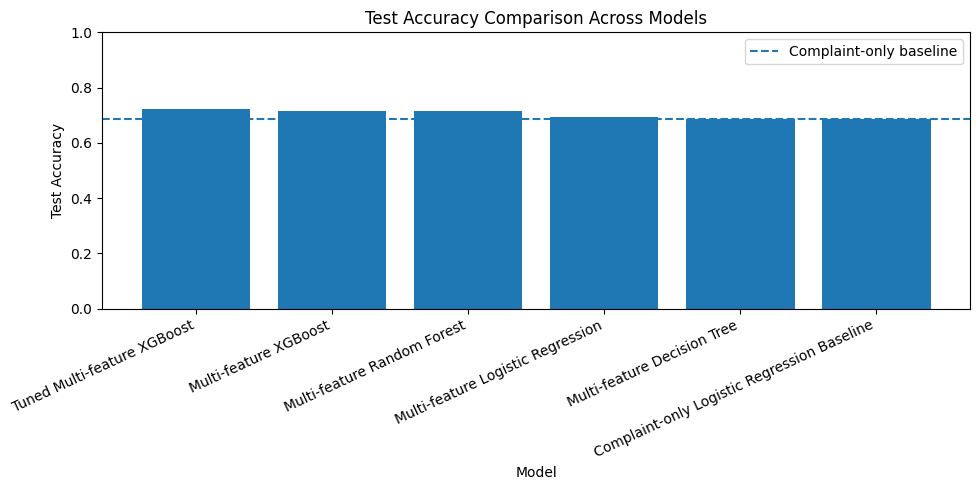

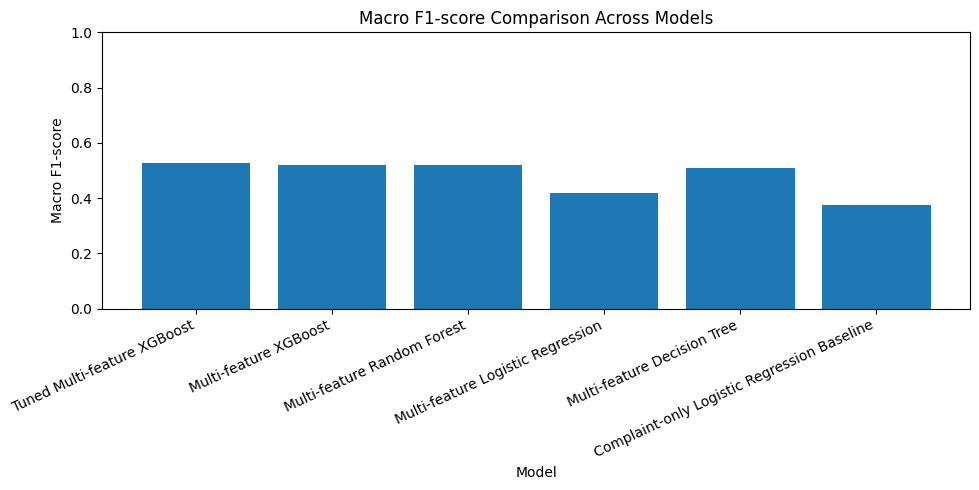

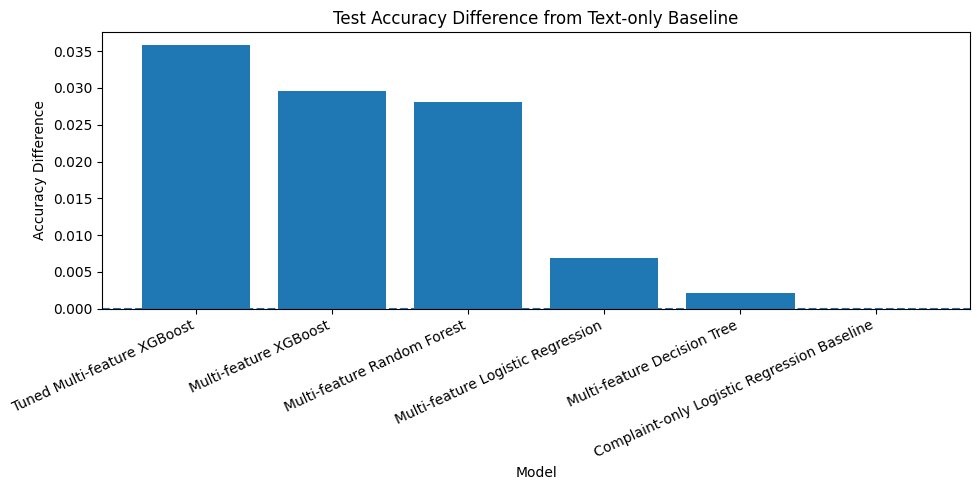

In [25]:
# Use the sorted results from Step 17
plot_df = results_df_sorted.copy()

# -------------------------------
# 1. Test accuracy comparison
# -------------------------------
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["Test Accuracy"])
plt.axhline(
    y=baseline_test_accuracy,
    linestyle="--",
    label="Complaint-only baseline"
)
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------
# 2. Macro F1 comparison
# -------------------------------
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["Macro F1"])
plt.ylim(0, 1)
plt.title("Macro F1-score Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# -------------------------------
# 3. Improvement over baseline
# -------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    plot_df["Model"],
    plot_df["Test Accuracy Difference from Baseline"]
)
plt.axhline(y=0, linestyle="--")
plt.title("Test Accuracy Difference from Text-only Baseline")
plt.xlabel("Model")
plt.ylabel("Accuracy Difference")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Step 21: Final summary and interpretation

This notebook reproduced the previous group's Task 1 triage acuity modelling approach using our current Task 1 dataset.

The final experiment used one-hot encoded chief complaint features, vital signs, and selected early categorical features. Records with missing vital signs were removed, obvious vital sign outliers were excluded, and acuity level 5 was removed. Therefore, the final modelling task became a four-class classification problem using acuity levels 1–4.

The complaint-only Logistic Regression model was used as the baseline. It achieved a test accuracy of **0.6854**, a macro F1-score of **0.3754**, and a weighted F1-score of **0.6678**. This baseline only used chief complaint features, so it provided a reference point for evaluating whether vital signs and early categorical features improved the prediction.

The multi-feature models generally improved performance compared with the complaint-only baseline. The best-performing model was the **Tuned Multi-feature XGBoost** model, which achieved a test accuracy of **0.7212**, a macro F1-score of **0.5271**, and a weighted F1-score of **0.7197**. Compared with the baseline, this represents an improvement of approximately **3.58 percentage points** in test accuracy.

The results suggest that adding vital signs and early categorical features provides useful additional predictive value for triage acuity prediction. The improvement in macro F1-score is also important, because it indicates that the tuned XGBoost model improved not only overall accuracy but also the average performance across acuity classes.

Among the reproduced models, XGBoost and Random Forest performed better than Logistic Regression and Decision Tree. The original XGBoost and Random Forest models achieved similar test accuracies, but their training accuracies were noticeably higher than their testing accuracies, suggesting some overfitting. After hyperparameter tuning, the tuned XGBoost model achieved the highest test accuracy while maintaining a smaller gap between training and testing accuracy, indicating better generalisation.

Although the results improved after following the previous group's data preparation strategy, the task remains challenging because the acuity classes are still imbalanced. Therefore, accuracy alone should not be used as the only evaluation metric. Macro F1-score, weighted F1-score, and confusion matrices are also important for understanding how well the models perform across different acuity levels.

Overall, the tuned multi-feature XGBoost model was selected as the best-performing model in this experiment. This reproduction experiment provides a fairer comparison with the previous group's approach because it uses a similar feature engineering strategy, excludes acuity level 5, and evaluates the models in a four-class acuity prediction setting.

Future improvements could include further hyperparameter tuning, applying class weighting, testing resampling methods, adding more clinically relevant early-stage features, or comparing the four-class setting with the original five-class setting.

In [26]:
# Final best model summary

best_model_row = results_df_sorted.iloc[0]

print("Best performing model:")
print(best_model_row["Model"])

print("\nTest accuracy:")
print(round(best_model_row["Test Accuracy"], 4))

print("\nWeighted F1-score:")
print(round(best_model_row["Weighted F1"], 4))

print("\nImprovement over text-only baseline:")
print(round(best_model_row["Test Accuracy Difference from Baseline"], 4))

Best performing model:
Tuned Multi-feature XGBoost

Test accuracy:
0.7212

Weighted F1-score:
0.7197

Improvement over text-only baseline:
0.0358


## Step 22: Create triage safety metrics table

This step creates a triage-focused comparison table similar to the previous group's evaluation table.

In addition to accuracy, macro precision, macro recall, macro F1-score, and ROC-AUC, this step calculates under-triage and over-triage rates.

For this experiment, acuity levels 1 and 2 are treated as urgent cases, while acuity levels 3 and 4 are treated as non-urgent cases.

Under-triage means that a truly urgent patient is predicted as non-urgent. This is clinically risky because it may delay care for patients who need urgent treatment.

Over-triage means that a truly non-urgent patient is predicted as urgent. This is less dangerous than under-triage, but it may waste emergency department resources.

In [27]:
# Create triage safety metrics table

URGENT_CUTOFF = 2
# Acuity 1 and 2 are treated as urgent.
# Acuity 3 and 4 are treated as non-urgent.

def calculate_under_over_triage(y_true, y_pred, urgent_cutoff=2):
    """
    Calculate under-triage and over-triage rates.

    Under-triage:
    True acuity is urgent (1 or 2), but predicted acuity is non-urgent (3 or 4).

    Over-triage:
    True acuity is non-urgent (3 or 4), but predicted acuity is urgent (1 or 2).
    """
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)

    true_urgent = y_true <= urgent_cutoff
    true_non_urgent = y_true > urgent_cutoff

    under_triage_count = ((true_urgent) & (y_pred > urgent_cutoff)).sum()
    over_triage_count = ((true_non_urgent) & (y_pred <= urgent_cutoff)).sum()

    under_triage_rate = under_triage_count / true_urgent.sum() * 100
    over_triage_rate = over_triage_count / true_non_urgent.sum() * 100

    return under_triage_rate, over_triage_rate


def align_probabilities(proba, model_classes, target_classes):
    """
    Align predicted probability columns with the target class order.
    This is needed because different models may store classes in different formats.
    """
    proba_df = pd.DataFrame(0.0, index=range(proba.shape[0]), columns=target_classes)

    for i, cls in enumerate(model_classes):
        if cls in proba_df.columns:
            proba_df[cls] = proba[:, i]

    return proba_df[target_classes].values


def calculate_multiclass_roc_auc(y_true, y_proba, model_classes, target_classes):
    """
    Calculate macro ROC-AUC for multi-class classification.
    """
    aligned_proba = align_probabilities(y_proba, model_classes, target_classes)

    try:
        auc = roc_auc_score(
            y_true,
            aligned_proba,
            labels=target_classes,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        auc = np.nan

    return auc


def add_triage_metrics_row(model_name, y_true, y_pred, y_proba, model_classes):
    """
    Create one row for the triage safety metrics comparison table.
    """
    under_triage, over_triage = calculate_under_over_triage(
        y_true,
        y_pred,
        urgent_cutoff=URGENT_CUTOFF
    )

    roc_auc = calculate_multiclass_roc_auc(
        y_true,
        y_proba,
        model_classes,
        class_labels
    )

    return {
        "Model": model_name,
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100,
        "Under-triage (%)": under_triage,
        "Over-triage (%)": over_triage,
        "ROC-AUC": roc_auc,
        "Precision (Macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-Score (Macro)": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }


triage_metrics_rows = []

# 1. Complaint-only Logistic Regression baseline
y_test_pred_baseline = baseline_model.predict(X_test_baseline)
y_test_proba_baseline = baseline_model.predict_proba(X_test_baseline)

triage_metrics_rows.append(
    add_triage_metrics_row(
        "Complaint-only Logistic Regression Baseline",
        y_test,
        y_test_pred_baseline,
        y_test_proba_baseline,
        baseline_model.classes_
    )
)


# 2. Multi-feature Logistic Regression
y_test_pred_logistic = logistic_model.predict(X_test_multi)
y_test_proba_logistic = logistic_model.predict_proba(X_test_multi)

triage_metrics_rows.append(
    add_triage_metrics_row(
        "Multi-feature Logistic Regression",
        y_test,
        y_test_pred_logistic,
        y_test_proba_logistic,
        logistic_model.classes_
    )
)


# 3. Multi-feature Decision Tree
y_test_pred_tree = decision_tree_model.predict(X_test_multi)
y_test_proba_tree = decision_tree_model.predict_proba(X_test_multi)

triage_metrics_rows.append(
    add_triage_metrics_row(
        "Multi-feature Decision Tree",
        y_test,
        y_test_pred_tree,
        y_test_proba_tree,
        decision_tree_model.classes_
    )
)


# 4. Multi-feature Random Forest
y_test_pred_rf = random_forest_model.predict(X_test_multi)
y_test_proba_rf = random_forest_model.predict_proba(X_test_multi)

triage_metrics_rows.append(
    add_triage_metrics_row(
        "Multi-feature Random Forest",
        y_test,
        y_test_pred_rf,
        y_test_proba_rf,
        random_forest_model.classes_
    )
)


# 5. Multi-feature XGBoost
# XGBoost predictions are encoded, so convert them back to original acuity labels.
y_test_pred_xgb_encoded = xgboost_model.predict(X_test_multi)
y_test_pred_xgb = label_encoder.inverse_transform(y_test_pred_xgb_encoded.astype(int))
y_test_proba_xgb = xgboost_model.predict_proba(X_test_multi)

triage_metrics_rows.append(
    add_triage_metrics_row(
        "Multi-feature XGBoost",
        y_test,
        y_test_pred_xgb,
        y_test_proba_xgb,
        label_encoder.classes_
    )
)


# 6. Tuned Multi-feature XGBoost
# This section only runs if best_xgb_model exists.
try:
    y_test_pred_tuned_xgb_encoded = best_xgb_model.predict(X_test_multi)
    y_test_pred_tuned_xgb = label_encoder.inverse_transform(y_test_pred_tuned_xgb_encoded.astype(int))
    y_test_proba_tuned_xgb = best_xgb_model.predict_proba(X_test_multi)

    triage_metrics_rows.append(
        add_triage_metrics_row(
            "Tuned Multi-feature XGBoost",
            y_test,
            y_test_pred_tuned_xgb,
            y_test_proba_tuned_xgb,
            label_encoder.classes_
        )
    )

except NameError:
    print("Tuned XGBoost model was not found. Skipping tuned XGBoost in the triage metrics table.")


# Create final table
triage_metrics_df = pd.DataFrame(triage_metrics_rows)

triage_metrics_df = triage_metrics_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(
    triage_metrics_df.round({
        "Accuracy (%)": 1,
        "Under-triage (%)": 1,
        "Over-triage (%)": 1,
        "ROC-AUC": 3,
        "Precision (Macro)": 3,
        "Recall (Macro)": 3,
        "F1-Score (Macro)": 3
    })
)

,Model,Accuracy (%),Under-triage (%),Over-triage (%),ROC-AUC,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Tuned Multi-feature XGBoost,72.1,20.5,29.8,0.848,0.545,0.513,0.527
1,Multi-feature XGBoost,71.5,21.0,30.3,0.835,0.540,0.504,0.519
2,Multi-feature Random Forest,71.3,20.7,31.3,0.853,0.542,0.503,0.520
3,Multi-feature Logistic Regression,69.2,22.8,30.3,0.838,0.493,0.404,0.420
4,Multi-feature Decision Tree,68.8,24.0,33.5,0.815,0.527,0.495,0.509
5,Complaint-only Logistic Regression Baseline,68.5,21.4,33.4,0.807,0.475,0.374,0.375
